# Text-to-Image and Image-to-image search Using CLIP

<div style="border:1px solid #ccc; border-radius:6px; padding:12px;">

<br>
<b>About</b><br><br>

This notebook is derived from the following notebook, with modifications and extensions: https://github.com/AI-Engineering-bootcamp/ai-eng-nbs-public/blob/master/clip-text-image-search-202504.ipynb
</div>

## Intro

In this notebook we'll build a system that can search for images using either **text** or another **image** as the query — no manual tagging required.

To do this, we'll use **CLIP** (Contrastive Language-Image Pre-training), a model developed by OpenAI that learns to represent both images and text in the *same* vector space. This means a caption like `"a dog playing in the snow"` and a photo of a dog playing in the snow will end up with very similar embeddings (vectors). This makes it possible to compare text and images directly using similarity search, the same way we compare embeddings of two pieces of text.

<br>

![](../_images/clip-model.jpg)

<br>

Here's a short video explaining the core ideas of CLIP:
- https://www.youtube.com/shorts/qHUs1OvWh-E

<br>

And, here's what we'll cover, step by step:

1. **Load and explore a dataset** of images and their captions.
2. **Load the CLIP model** and use it to generate embeddings for both text and images.
3. **Implement similarity search from scratch**, using cosine similarity to find the images that best match a text query or another image.
4. **Use a vector database (Pinecone)** to store our image embeddings and perform the same kind of search at scale, the way you would in a real-world production system.

By the end, you'll understand how multimodal search works, why CLIP is such a powerful model for it, and how to move from a simple in-memory search to a proper vector database setup.


## Import libraries

In [ ]:
# !pip install datasets==5.0.1
# !pip install torch==2.13.0
# !pip install requests==2.34.2
# !pip install pandas==3.0.5
# !pip install Pillow==12.3.0
# !pip install transformers==5.14.1
# !pip install matplotlib==3.11.1
# !pip install scikit-learn==1.9.0

  Using cached scikit_learn-1.9.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-macosx_12_0_arm64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import torch
import requests
import pandas as pd
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer

/Users/luis/Desktop/ironhack_june26/1_ai_eng_lectures/.venv/langchain-v0.2.x/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Image Exploration

### Load Data

In [2]:
# https://huggingface.co/datasets/google-research-datasets/conceptual_captions
image_data = load_dataset(
    "google-research-datasets/conceptual_captions", split="train",
    )

In [3]:
image_data

Dataset({
    features: ['image_url', 'caption'],
    num_rows: 3318333
})

We will select a sample of 100 datapoints from this large number of images (3 318 333)

Let's examine how the dataset is structured

In [4]:
image_data_df = pd.DataFrame(image_data[:100])

In [5]:
image_data_df

,image_url,caption
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...
2,https://media.gettyimages.com/photos/young-con...,young confused girl standing in front of a war...
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .
...,...,...
95,https://i.pinimg.com/736x/83/ab/4f/83ab4fbbb6a...,actor is an actor who started out as a lawyer .
96,https://i.pinimg.com/736x/58/2a/ec/582aecd2587...,color good with green couch in living room ......
97,http://www.fourintravels.com/wp-content/upload...,the villas from the front
98,https://ak8.picdn.net/shutterstock/videos/5281...,tree branches swing at real time with the wind...


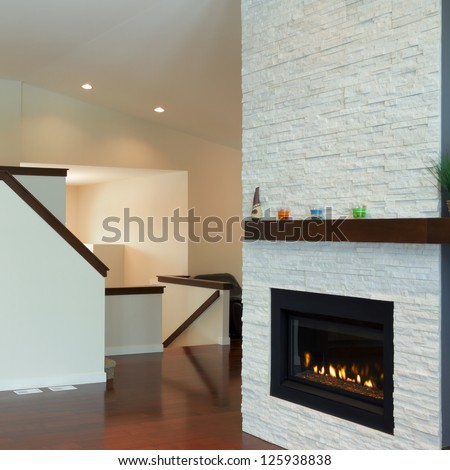

In [6]:
# Let's see one of those images
img_url = image_data_df.iloc[3]["image_url"]
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
image

In [7]:
# and, here's the caption associated to it
image_data_df.iloc[3]["caption"]

'interior design of modern living room with fireplace in a new house'

In [8]:
#
# Let's also define a few functions what we'll use later
#

def check_valid_URLs(image_URL):
    """
    Check whether the given image URL points to a valid image.
    """
    try:
      response = requests.get(image_URL)
      Image.open(BytesIO(response.content))
      return True
    except:
      return False


def get_image(image_URL):
    """
    Download an image from a URL and return it as an RGB PIL Image.
    """
    response = requests.get(image_URL)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return image


def get_image_caption(image_ID):
    """
    Return the caption associated with the given image ID.
    """
    return image_data[image_ID]["caption"]

In [9]:
# Transform dataframe, adding a new column "is_valid"
image_data_df["is_valid"] = image_data_df["image_url"].apply(check_valid_URLs)

In [10]:
image_data_df["is_valid"].value_counts()

is_valid
False    51
True     49
Name: count, dtype: int64

In [11]:
image_data_df = image_data_df[image_data_df["is_valid"]==True]
image_data_df.head()

,image_url,caption,is_valid
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True


In [12]:
image_data_df["image"] = image_data_df["image_url"].apply(get_image)

/Users/luis/Desktop/ironhack_june26/1_ai_eng_lectures/.venv/langchain-v0.2.x/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


a very typical bus station


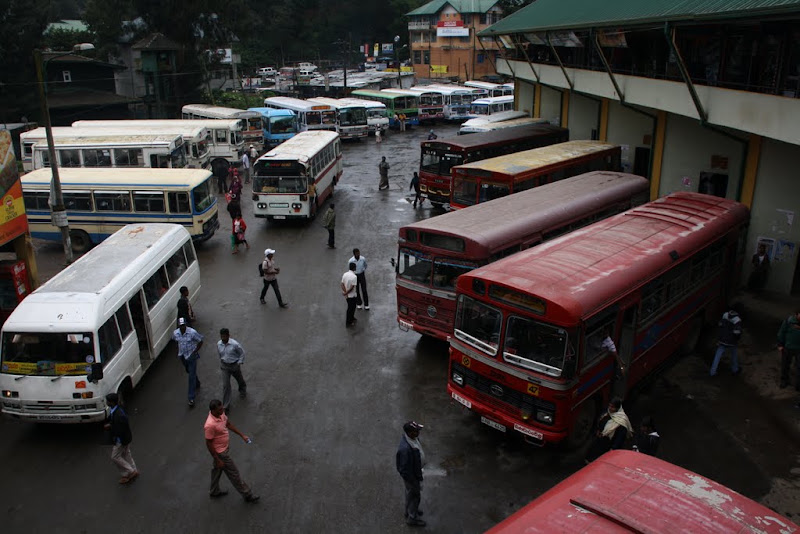

In [30]:
# let's see an example
print(image_data_df.iloc[0]["caption"])
image_data_df.iloc[0]["image"]

## Load the model

In [38]:
# Load the three main CLIP components:
# - model: the neural network that generates image and text embeddings.
# - processor: prepares raw inputs (e.g., images and text) into the format
#   expected by the model by combining image preprocessing and text processing.
# - tokenizer: converts raw text into token IDs that the model can understand.
#   It is included separately for cases where only text tokenization is needed.


def get_model_info(model_ID, device):

  # Save the model to device
  model = CLIPModel.from_pretrained(model_ID).to(device)

  # Get the processor
  processor = CLIPProcessor.from_pretrained(model_ID)

  # Get the tokenizer
  tokenizer = CLIPTokenizer.from_pretrained(model_ID)

  # Return model, processor & tokenizer
  return model, processor, tokenizer

In [39]:
# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ID = "openai/clip-vit-base-patch32"

model, processor, tokenizer = get_model_info(model_ID, device)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 42157.00it/s]


## Create Embeddings: Text and Image Embeddings

### Text Embeddings

To compare text and images, we first need to turn text into an embedding (a vector of numbers) using CLIP's text encoder. The function below takes a single piece of text (e.g., a caption) and returns its embedding.

In [40]:
def get_single_text_embedding(text):

  # Tokenize the text (convert it into the numeric input format CLIP expects)
  inputs = tokenizer(text, return_tensors = "pt").to(device)

  # Pass the tokenized text through CLIP's text encoder to get its embedding.
  # Note: this version of transformers returns a BaseModelOutputWithPooling
  # object rather than a plain tensor, so we grab the embedding from .pooler_output
  text_embeddings = model.get_text_features(**inputs).pooler_output

  # convert the embeddings to numpy array 
  embedding_as_np = text_embeddings.cpu().detach().numpy()

  return embedding_as_np

In [41]:
def get_all_text_embeddings(df, text_col):
   # Apply the function "get_single_text_embedding" to every row in the given column,
   # storing each resulting embedding in a new "text_embeddings" column
   df["text_embeddings"] = df[str(text_col)].apply(get_single_text_embedding)
   return df 


In [42]:
image_data_df = get_all_text_embeddings(image_data_df, "caption")

In [43]:
image_data_df.head()

,image_url,caption,is_valid,image,text_embeddings
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True,<PIL.Image.Image image mode=RGB size=800x534 a...,"[[0.25922295, -0.0882593, 0.020317419, -0.1270..."
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True,<PIL.Image.Image image mode=RGB size=500x441 a...,"[[0.004146993, 0.18943514, -0.12396985, 0.3029..."
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.5606448, -0.15138124, -0.43740296, -0.3392..."
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.03529205, 0.242627, -0.12724778, -0.210213..."
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True,<PIL.Image.Image image mode=RGB size=1200x678 ...,"[[0.18494701, 0.37737134, 0.23176071, -0.14631..."


<br>

### Image Embeddings

In [47]:
def get_single_image_embedding(my_image):
  image = processor(
      text = None,
      images = my_image, 
      return_tensors="pt"
  )["pixel_values"].to(device)

  # Note: this version of transformers returns a BaseModelOutputWithPooling
  # object rather than a plain tensor, so we grab the embedding from .pooler_output
  embedding = model.get_image_features(image).pooler_output

  # convert the embeddings to numpy array
  embedding_as_np = embedding.cpu().detach().numpy()

  return embedding_as_np

In [48]:
def get_all_images_embedding(df, img_column):
  df["img_embeddings"] = df[str(img_column)].apply(get_single_image_embedding)
  return df

In [49]:
image_data_df = get_all_images_embedding(image_data_df, "image")

In [50]:
image_data_df.head()

,image_url,caption,is_valid,image,text_embeddings,img_embeddings
0,http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...,a very typical bus station,True,<PIL.Image.Image image mode=RGB size=800x534 a...,"[[0.25922295, -0.0882593, 0.020317419, -0.1270...","[[-0.010698811, -0.06217542, 0.35432926, 0.307..."
1,http://78.media.tumblr.com/3b133294bdc7c7784b7...,sierra looked stunning in this top and this sk...,True,<PIL.Image.Image image mode=RGB size=500x441 a...,"[[0.004146993, 0.18943514, -0.12396985, 0.3029...","[[-0.25033987, -0.13193838, 0.096613586, 0.978..."
3,https://thumb1.shutterstock.com/display_pic_wi...,interior design of modern living room with fir...,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.5606448, -0.15138124, -0.43740296, -0.3392...","[[-0.16001259, -0.29561353, -0.11368221, -0.04..."
4,https://thumb1.shutterstock.com/display_pic_wi...,cybernetic scene isolated on white background .,True,<PIL.Image.Image image mode=RGB size=450x470 a...,"[[0.03529205, 0.242627, -0.12724778, -0.210213...","[[0.18146762, 0.051112212, -0.64071316, -0.078..."
6,https://prismpub.com/wp-content/uploads/2016/1...,the jetty : different types of plants to estab...,True,<PIL.Image.Image image mode=RGB size=1200x678 ...,"[[0.18494701, 0.37737134, 0.23176071, -0.14631...","[[0.054560203, -0.13580832, -0.0030716544, -0...."


<br>

### Helper function to plot images

In [53]:
import matplotlib.pyplot as plt

def plot_images(images):

  for image in images:
    plt.imshow(image)
    plt.show()

def plot_images_by_side(top_images):

  index_values = list(top_images.index.values)
  list_images = [top_images.iloc[idx].image for idx in index_values] 
  list_captions = [top_images.iloc[idx].caption for idx in index_values] 
  similarity_score = [top_images.iloc[idx].cos_sim for idx in index_values] 

  n_row = n_col = 2

  _, axs = plt.subplots(n_row, n_col, figsize=(12, 12))
  axs = axs.flatten()
  for img, ax, caption, sim_score in zip(list_images, axs, list_captions, similarity_score):
      ax.imshow(img)
      sim_score = 100*float("{:.2f}".format(sim_score))
      ax.title.set_text(f"Caption: {caption}\nSimilarity: {sim_score}%")
  plt.show()

<br>

## Perform Similarity Search: Cosine 

### 1. Cosine Similarity Search

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def get_top_N_images(query, data, top_K=4, search_criterion="text"):

    """
    Retrieve top_K (5 is default value) articles similar to the query
    """
    # Text to image Search
    if(search_criterion.lower() == "text"):
      query_vect = get_single_text_embedding(query)

    # Image to image Search
    else: 
      query_vect = get_single_image_embedding(query)

    # Relevant columns
    revevant_cols = ["caption", "image", "cos_sim"]
    
    # Run similarity Search
    data["cos_sim"] = data["img_embeddings"].apply(lambda x: cosine_similarity(query_vect, x))

    data["cos_sim"] = data["cos_sim"].apply(lambda x: x[0][0])
    
    """
    Sort Cosine Similarity Column in Descending Order 
    Here we start at 1 to remove similarity with itself because it is always 1
    """
    most_similar_articles = data.sort_values(by='cos_sim', ascending=False)[1:top_K+1]
    
    return most_similar_articles[revevant_cols].reset_index()

In [ ]:
image_data_df.columns

#### a. Text to image search

In [ ]:
query_caption = image_data_df.iloc[10].caption

top_images = get_top_N_images(query_caption, image_data_df)
print("Query: {}".format(query_caption))
top_images

In [ ]:
plot_images_by_side(top_images)

#### b. Image to image search

In [ ]:
query_image = image_data_df.iloc[0].image
query_image

In [ ]:
top_images = get_top_N_images(query_image, image_data_df, search_criterion="image")
plot_images_by_side(top_images)

# Approach n°2: Pinecone Client Library

#### Initializing the Index

Now we need a place to store these embeddings and enable a efficient vector search through them all. To do that we use Pinecone, we can get a [free API key](https://app.pinecone.io/) and enter it below where we will initialize our connection to Pinecone and create a new index.

In [ ]:
# !pip install -qU langchain-pinecone pinecone-notebooks

In [ ]:
import os
from pinecone import Pinecone
from dotenv import load_dotenv, find_dotenv

_ = load_dotenv(find_dotenv())
api_key = os.environ.get('PINECONE_API_KEY') or 'PINECONE_API_KEY'

# configure client
pc = Pinecone(api_key=api_key)

Now we setup our index specification, this allows us to define the cloud provider and region where we want to deploy our index. You can find a list of all [available providers and regions here](https://docs.pinecone.io/docs/projects).

In [ ]:
from pinecone import ServerlessSpec

cloud = os.environ.get('PINECONE_CLOUD') or 'aws'
region = os.environ.get('PINECONE_REGION') or 'us-east-1'

spec = ServerlessSpec(cloud=cloud, region=region)

Create the index:

In [ ]:
my_index_name = "clip-image-search"

In [ ]:
import time

vector_dim = image_data_df.img_embeddings[0].shape[1]

# check if index already exists (it shouldn't if this is first time)
if my_index_name not in pc.list_indexes().names():
    # if does not exist, create index
    pc.create_index(
        my_index_name,
        dimension=vector_dim,
        metric='cosine',
        spec=spec
    )
    # wait for index to be initialized
    while not pc.describe_index(my_index_name).status['ready']:
        time.sleep(1)

# connect to index
my_index = pc.Index(my_index_name)
# view index stats
my_index.describe_index_stats()

#### Prepare Vector

In [ ]:
image_data_df["vector_id"] = image_data_df.index
image_data_df["vector_id"] = image_data_df["vector_id"].apply(str)

# Get all the metadata
final_metadata = []

for index in range(len(image_data_df)):
  final_metadata.append({
      'ID':  index,
      'caption': image_data_df.iloc[index].caption, 
      'image': image_data_df.iloc[index].image_url
  })

image_IDs = image_data_df.vector_id.tolist()
image_embeddings = [arr.flatten().tolist() for arr in image_data_df.img_embeddings.tolist()] 

# Create the single list of dictionary format to insert 
data_to_upsert = list(zip(image_IDs, image_embeddings, final_metadata))

# Upload the final data
my_index.upsert(vectors = data_to_upsert)

# Check index size for each namespace
my_index.describe_index_stats()

### Text to image

In [ ]:
text_query = image_data_df.iloc[10].caption
text_query

In [ ]:
# Get the caption embedding
query_embedding = get_single_text_embedding(text_query).tolist()

In [ ]:
# Run the query
my_index.query(vector=query_embedding, top_k=4, include_metadata=True)

### Image to image

In [ ]:
image_query = image_data_df.iloc[0].image
image_query

In [ ]:
# Get the text embedding
query_embedding = get_single_image_embedding(image_query).tolist()

In [ ]:
# Run the query
my_index.query(vector=query_embedding, top_k=4, include_metadata=True)

#### Delete your index

Once finished with the index we can delete it to save resources.

In [ ]:
# pc.delete_index(my_index_name)